In [125]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sahilhussain2410/nyneos-dataset-genai/dataset/test.csv


In [126]:
df=pd.read_csv("/kaggle/input/datasets/sahilhussain2410/nyneos-dataset-genai/dataset/test.csv")

In [127]:
df.shape

(381952, 15)

In [128]:
df.head()

,time,channel,PRN,Carrier_Doppler_hz,Pseudorange_m,RX_time,TOW,Carrier_phase,EC,LC,PC,PIP,PQP,TCD,CN0
0,111402,ch0,8,4749.068417,4.841489e+06,263154.82,263154.803851,-435396.111594,101998.429688,100788.812500,111415.289062,-107731.039062,-28414.615234,4660.467773,43.559540
1,111402,ch1,9,1995.777378,2.449848e+06,263154.82,263154.811828,-201479.950180,100812.039062,98424.367188,109174.476562,-105347.234375,-28653.570312,1997.164185,47.116425
2,111402,ch2,27,3458.024120,3.738822e+06,263154.82,263154.807529,-356000.635312,138335.140625,125640.570312,138446.281250,137254.781250,-18124.476562,3467.803955,45.687332
3,111402,ch3,26,-2105.992470,5.482371e+06,263154.82,263154.801713,193102.504674,84470.195312,84153.156250,95917.468750,95899.140625,1874.903442,-2109.972656,42.264256
4,111402,ch4,4,-493.638193,2.666526e+06,263154.82,263154.811105,48203.346004,103226.210938,100365.203125,114574.656250,-114160.539062,-9732.571289,-494.215881,43.629795


In [129]:
# Check rows per timestamp
counts = df.groupby("time").size()

print(counts.value_counts())

8    47744
Name: count, dtype: int64


In [130]:
features = [
    "PRN",
    "Carrier_Doppler_hz",
    "Pseudorange_m",
    "RX_time",
    "TOW",
    "Carrier_phase",
    "EC", "LC", "PC",
    "PIP", "PQP",
    "TCD",
    "CN0"
]

In [131]:
def reshape_timestamp(group):
    # group: 8 rows for one timestamp
    
    # sort by channel to maintain consistency
    group = group.sort_values("channel")
    
    # extract feature values
    values = group[features].values  # shape: (8, F)
    
    # flatten → (8*F,)
    flat = values.flatten()
    
    return pd.Series(flat)


df_agg = df.groupby("time").apply(reshape_timestamp)
df_agg.reset_index(inplace=True)

/tmp/ipykernel_55/1064103259.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_agg = df.groupby("time").apply(reshape_timestamp)


In [132]:
print(df_agg.shape)
df_agg.head()


(47744, 105)


,time,0,1,2,3,4,5,6,7,8,...,94,95,96,97,98,99,100,101,102,103
0,111402,8.0,4749.068417,4.841489e+06,263154.82,263154.803851,-435396.111594,101998.429688,100788.812500,111415.289062,...,263154.82,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,111403,8.0,4745.420835,4.841471e+06,263154.84,263154.823851,-435491.131833,114237.742188,110539.609375,113200.921875,...,263154.84,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,111404,8.0,4751.120747,4.841452e+06,263154.86,263154.843851,-435586.173923,98196.671875,101903.156250,105292.015625,...,263154.86,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,111405,8.0,4753.643721,4.841434e+06,263154.88,263154.863851,-435681.222670,110324.953125,108914.406250,123395.671875,...,263154.88,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,111406,8.0,4756.228404,4.841415e+06,263154.90,263154.883851,-435776.256737,85548.117188,85156.445312,97768.617188,...,263154.90,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [133]:
new_cols = []

for ch in range(8):
    for f in features:
        new_cols.append(f"{f}_ch{ch}")

df_agg.columns = ["time"] + new_cols

In [134]:
print(df_agg.shape)
df_agg.head()


(47744, 105)


,time,PRN_ch0,Carrier_Doppler_hz_ch0,Pseudorange_m_ch0,RX_time_ch0,TOW_ch0,Carrier_phase_ch0,EC_ch0,LC_ch0,PC_ch0,...,RX_time_ch7,TOW_ch7,Carrier_phase_ch7,EC_ch7,LC_ch7,PC_ch7,PIP_ch7,PQP_ch7,TCD_ch7,CN0_ch7
0,111402,8.0,4749.068417,4.841489e+06,263154.82,263154.803851,-435396.111594,101998.429688,100788.812500,111415.289062,...,263154.82,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,111403,8.0,4745.420835,4.841471e+06,263154.84,263154.823851,-435491.131833,114237.742188,110539.609375,113200.921875,...,263154.84,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,111404,8.0,4751.120747,4.841452e+06,263154.86,263154.843851,-435586.173923,98196.671875,101903.156250,105292.015625,...,263154.86,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,111405,8.0,4753.643721,4.841434e+06,263154.88,263154.863851,-435681.222670,110324.953125,108914.406250,123395.671875,...,263154.88,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,111406,8.0,4756.228404,4.841415e+06,263154.90,263154.883851,-435776.256737,85548.117188,85156.445312,97768.617188,...,263154.90,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [135]:
# remove incomplete timestamps
valid_times = counts[counts == 8].index
df = df[df["time"].isin(valid_times)]

In [136]:
df.groupby(["time", "channel"]).size().value_counts()

1    381952
Name: count, dtype: int64

# Feature Engineering

In [137]:
df.shape

(381952, 15)

In [138]:
df["doppler_diff"] = df.groupby("channel")["Carrier_Doppler_hz"].diff()
df["doppler_diff2"] = df.groupby("channel")["doppler_diff"].diff()

In [139]:
df["range_diff"] = df.groupby("channel")["Pseudorange_m"].diff()

In [140]:
df["phase_diff"] = df.groupby("channel")["Carrier_phase"].diff()

In [141]:
window = 5

df["range_roll_mean"] = df.groupby("channel")["Pseudorange_m"].rolling(window).mean().reset_index(0, drop=True)
df["range_roll_std"]  = df.groupby("channel")["Pseudorange_m"].rolling(window).std().reset_index(0, drop=True)

df["doppler_roll_std"] = df.groupby("channel")["Carrier_Doppler_hz"].rolling(window).std().reset_index(0, drop=True)

In [142]:
k = 3

df["range_jump"] = (abs(df["range_diff"]) > k * df["range_roll_std"]).astype(int)
df["doppler_jump"] = (abs(df["doppler_diff"]) > k * df["doppler_roll_std"]).astype(int)

## Signal processing feature

In [143]:
df["corr_symmetry"] = abs(df["EC"] - df["LC"])

In [144]:
df["ec_pc_diff"] = abs(df["EC"] - df["PC"])
df["lc_pc_diff"] = abs(df["LC"] - df["PC"])

In [145]:
eps = 1e-6

df["power_ratio"] = df["PIP"] / (df["PQP"] + eps)
df["power_total"] = df["PIP"] + df["PQP"]
df["power_log_ratio"] = np.log(df["power_ratio"] + eps)

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [146]:
df["time_gap"] = df["RX_time"] - df["TOW"]

In [147]:
df["ec_ratio"] = df["EC"] / (df["PC"] + eps)
df["lc_ratio"] = df["LC"] / (df["PC"] + eps)

## Cross satelite feature

In [148]:
grouped = df.groupby("time")

In [149]:
cn0_stats = grouped["CN0"].agg(["mean", "std"]).rename(columns={
    "mean": "cn0_mean",
    "std": "cn0_std"
})

In [150]:
range_stats = grouped["Pseudorange_m"].agg(["mean", "std"]).rename(columns={
    "mean": "range_mean",
    "std": "range_std"
})

In [151]:
doppler_stats = grouped["Carrier_Doppler_hz"].agg(["mean", "std"]).rename(columns={
    "mean": "doppler_mean",
    "std": "doppler_std"
})

In [152]:
tcd_stats = grouped["TCD"].agg(["mean", "std"]).rename(columns={
    "mean": "tcd_mean",
    "std": "tcd_std"
})

In [153]:
sym_stats = grouped["corr_symmetry"].agg(["mean", "std"]).rename(columns={
    "mean": "sym_mean",
    "std": "sym_std"
})

## Merging full dataset

In [154]:
cross_features = pd.concat([
    cn0_stats,
    range_stats,
    doppler_stats,
    tcd_stats,
    sym_stats
], axis=1).reset_index()

In [155]:
df_final = df_agg.merge(cross_features, on="time", how="left")

In [156]:
df_final.shape
df_final.head()

,time,PRN_ch0,Carrier_Doppler_hz_ch0,Pseudorange_m_ch0,RX_time_ch0,TOW_ch0,Carrier_phase_ch0,EC_ch0,LC_ch0,PC_ch0,...,cn0_mean,cn0_std,range_mean,range_std,doppler_mean,doppler_std,tcd_mean,tcd_std,sym_mean,sym_std
0,111402,8.0,4749.068417,4.841489e+06,263154.82,263154.803851,-435396.111594,101998.429688,100788.812500,111415.289062,...,27.782168,23.051986,2.397382e+06,2.223504e+06,950.404907,2266.130624,940.155922,2247.518556,2433.738281,4296.468474
1,111403,8.0,4745.420835,4.841471e+06,263154.84,263154.823851,-435491.131833,114237.742188,110539.609375,113200.921875,...,27.803920,23.068548,2.397378e+06,2.223502e+06,950.138443,2265.073068,939.095234,2244.921937,5274.637695,9168.368957
2,111404,8.0,4751.120747,4.841452e+06,263154.86,263154.843851,-435586.173923,98196.671875,101903.156250,105292.015625,...,27.837077,23.093797,2.397375e+06,2.223499e+06,951.645918,2265.688394,939.197292,2244.920639,6583.956055,8863.585413
3,111405,8.0,4753.643721,4.841434e+06,263154.88,263154.863851,-435681.222670,110324.953125,108914.406250,123395.671875,...,27.848850,23.101450,2.397371e+06,2.223497e+06,951.887959,2267.244568,938.366837,2247.879712,8554.626465,9636.613171
4,111406,8.0,4756.228404,4.841415e+06,263154.90,263154.883851,-435776.256737,85548.117188,85156.445312,97768.617188,...,27.858460,23.108793,2.397368e+06,2.223494e+06,951.109377,2268.164323,938.328171,2245.928933,4134.537109,6282.908405


In [157]:

cnt=df_final.isna().sum()
print(cnt)
df_final = df_final.fillna(0)

time                      0
PRN_ch0                   0
Carrier_Doppler_hz_ch0    0
Pseudorange_m_ch0         0
RX_time_ch0               0
                         ..
doppler_std               0
tcd_mean                  0
tcd_std                   0
sym_mean                  0
sym_std                   0
Length: 115, dtype: int64


# Building Model

## Baseline Model

In [158]:
X = df_final.drop(columns=["time"])

In [159]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

In [160]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=42,
    n_jobs=-1
)

iso.fit(X_scaled)

IsolationForest(contamination=0.02, n_estimators=200, n_jobs=-1,
                random_state=42)

In [161]:
scores = iso.decision_function(X_scaled)   # higher = normal
anomaly_scores = -scores                   # higher = more anomalous


In [162]:
import numpy as np

threshold = np.percentile(anomaly_scores, 98)  

df_final["spoofed"] = (anomaly_scores > threshold).astype(int)

In [163]:
k = 10  

df_final["confidence"] = 1 / (1 + np.exp(-k * (anomaly_scores - threshold)))

In [164]:
## RUle base

# Rule 1: correlator symmetry
sym_thresh = df["corr_symmetry"].quantile(0.98)

# Rule 2: CN0 high anomaly
cn0_thresh = df["CN0"].quantile(0.98)

# Aggregate rule per timestamp
rule_flags = df.groupby("time").apply(
    lambda g: int(
        (g["corr_symmetry"].mean() > sym_thresh) or
        (g["CN0"].mean() > cn0_thresh)
    )
).reset_index(name="rule_spoofed")

/tmp/ipykernel_55/4294418351.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rule_flags = df.groupby("time").apply(


In [165]:
df_final = df_final.merge(rule_flags, on="time", how="left")

In [166]:
df_final["final_spoofed"] = (
    (df_final["spoofed"] == 1) | 
    (df_final["rule_spoofed"] == 1)
).astype(int)

In [167]:
submission = df_final[["time", "final_spoofed", "confidence"]].copy()

submission.columns = ["time", "spoofed", "confidence"]

submission.to_csv("submission.csv", index=False)

In [168]:
one=(submission['spoofed']==1).sum()
zer=47744-one
print(one)
print(zer)

955
46789


In [169]:
print(df_final["confidence"].describe())

count    47744.000000
mean         0.308062
std          0.110063
min          0.162586
25%          0.162586
50%          0.322815
75%          0.398063
max          0.564440
Name: confidence, dtype: float64


In [170]:
df_final[df_final["spoofed"] == 1]["time"].head(50)

45      111447
46      111448
69      111471
70      111472
74      111476
97      111499
100     111502
104     111506
109     111511
114     111516
118     111520
126     111528
133     111535
147     111549
152     111554
154     111556
156     111558
159     111561
166     111568
167     111569
168     111570
169     111571
170     111572
171     111573
177     111579
178     111580
182     111584
183     111585
188     111590
191     111593
192     111594
197     111599
198     111600
204     111606
206     111608
208     111610
211     111613
212     111614
217     111619
219     111621
225     111627
229     111631
241     111643
243     111645
245     111647
247     111649
250     111652
254     111656
1628    113030
1645    113047
Name: time, dtype: int64

## Intermediate

In [171]:
X = df_final.drop(columns=["time", "spoofed", "confidence"], errors="ignore").values

In [172]:
from sklearn.preprocessing import StandardScaler

scaler_dl = StandardScaler()
X_scaled = scaler_dl.fit_transform(X)

In [173]:
def create_sequences(data, window=20):
    sequences = []
    for i in range(len(data) - window):
        sequences.append(data[i:i+window])
    return np.array(sequences)

window_size = 20
X_seq = create_sequences(X_scaled, window_size)

print(X_seq.shape)  # (N, 20, features)

(47724, 20, 116)


### LSTM Encoder

In [174]:
import torch
import torch.nn as nn

class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features, hidden_size=64):
        super().__init__()
        
        self.encoder = nn.LSTM(n_features, hidden_size, batch_first=True)
        self.decoder = nn.LSTM(hidden_size, n_features, batch_first=True)

    def forward(self, x):
        _, (hidden, _) = self.encoder(x)
        hidden_repeated = hidden.repeat(x.size(1), 1, 1).permute(1,0,2)
        decoded, _ = self.decoder(hidden_repeated)
        return decoded

In [175]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

model = LSTMAutoencoder(n_features=X_seq.shape[2]).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

X_tensor = torch.tensor(X_seq, dtype=torch.float32).to(device)

cpu


In [176]:
epochs = 10

for epoch in range(epochs):
    model.train()
    
    optimizer.zero_grad()
    output = model(X_tensor)
    loss = criterion(output, X_tensor)
    
    loss.backward()
    optimizer.step()
    
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.9995
Epoch 2, Loss: 0.9859
Epoch 3, Loss: 0.9732
Epoch 4, Loss: 0.9605
Epoch 5, Loss: 0.9472
Epoch 6, Loss: 0.9329
Epoch 7, Loss: 0.9172
Epoch 8, Loss: 0.9000
Epoch 9, Loss: 0.8811
Epoch 10, Loss: 0.8608


In [177]:
model.eval()

with torch.no_grad():
    recon = model(X_tensor)
    errors = torch.mean((X_tensor - recon)**2, dim=(1,2)).cpu().numpy()

In [178]:
df_final["lstm_score"] = 0
df_final.loc[window_size:, "lstm_score"] = errors

/tmp/ipykernel_55/1928417156.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.1801676  1.1749371  1.168135   ... 0.91591585 0.922404   0.88514596]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_final.loc[window_size:, "lstm_score"] = errors


In [179]:
threshold_lstm = errors.mean() + 2 * errors.std()

df_final["lstm_spoofed"] = (df_final["lstm_score"] > threshold_lstm).astype(int)

In [180]:
df_final["final_spoofed"] = (
    (df_final["spoofed"] == 1) |
    (df_final["lstm_spoofed"] == 1)
).astype(int)

In [181]:
# combine scores
combined_score = anomaly_scores + df_final["lstm_score"]

# normalize
combined_score = (combined_score - combined_score.min()) / (combined_score.max() - combined_score.min())

df_final["confidence"] = combined_score

In [182]:
submission1 = df_final[["time", "final_spoofed", "confidence"]].copy()

submission1.columns = ["time", "spoofed", "confidence"]

submission1.to_csv("submission_lstm.csv", index=False)

In [183]:
one=(submission1['spoofed']==1).sum()
zer=47744-one
print(one)
print(zer)

1721
46023


### CNN

In [184]:
import torch.nn as nn

class CNNAutoencoder(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv1d(n_features, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(64, 32, kernel_size=3, padding=1),
            nn.ReLU()
        )
        
        self.decoder = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(64, n_features, kernel_size=3, padding=1)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)  # (batch, features, time)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded.permute(0, 2, 1)

In [185]:
model_cnn = CNNAutoencoder(n_features=X_seq.shape[2]).to(device)

optimizer = torch.optim.Adam(model_cnn.parameters(), lr=1e-3)
criterion = nn.MSELoss()

X_tensor = torch.tensor(X_seq, dtype=torch.float32).to(device)

for epoch in range(10):
    optimizer.zero_grad()
    output = model_cnn(X_tensor)
    loss = criterion(output, X_tensor)
    loss.backward()
    optimizer.step()
    
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.9969
Epoch 2, Loss: 0.9837
Epoch 3, Loss: 0.9714
Epoch 4, Loss: 0.9522
Epoch 5, Loss: 0.9233
Epoch 6, Loss: 0.8834
Epoch 7, Loss: 0.8327
Epoch 8, Loss: 0.7732
Epoch 9, Loss: 0.7117
Epoch 10, Loss: 0.6621


In [186]:
with torch.no_grad():
    recon = model_cnn(X_tensor)
    cnn_errors = torch.mean((X_tensor - recon)**2, dim=(1,2)).cpu().numpy()

In [187]:
df_final["cnn_score"] = 0
df_final.loc[window_size:, "cnn_score"] = cnn_errors

threshold_cnn = cnn_errors.mean() + 2 * cnn_errors.std()

df_final["cnn_spoofed"] = (df_final["cnn_score"] > threshold_cnn).astype(int)

/tmp/ipykernel_55/857957795.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.0668554  1.0651811  1.0624874  ... 0.96108985 0.96257913 0.9256739 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_final.loc[window_size:, "cnn_score"] = cnn_errors


In [191]:
df_final["vote_sum"] = (
    df_final["spoofed"] + 
    df_final["lstm_spoofed"] + 
    df_final["cnn_spoofed"]
)

df_final["final_spoofed"] = (df_final["vote_sum"] >= 2).astype(int)

In [192]:
df_final["vote_sum"].head()

0    0
1    0
2    0
3    0
4    0
Name: vote_sum, dtype: int64

In [193]:
df_final["confidence"] = df_final["vote_sum"] / 3

In [194]:
submission2 = df_final[["time", "final_spoofed", "confidence"]].copy()

submission2.columns = ["time", "spoofed", "confidence"]

submission2.to_csv("submission_lstm_CNN.csv", index=False)

In [195]:
df_final["final_spoofed"].value_counts()

final_spoofed
0    46783
1      961
Name: count, dtype: int64

## Combining

In [196]:
def normalize(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

df_final["iso_score"] = normalize(anomaly_scores)
df_final["lstm_score"] = normalize(df_final["lstm_score"])
df_final["cnn_score"] = normalize(df_final["cnn_score"])

In [197]:
df_final["rule_score"] = df_final["rule_spoofed"].astype(float)

In [198]:
w_iso  = 0.3
w_lstm = 0.4
w_cnn  = 0.2
w_rule = 0.1

df_final["fusion_score"] = (
    w_iso  * df_final["iso_score"] +
    w_lstm * df_final["lstm_score"] +
    w_cnn  * df_final["cnn_score"] +
    w_rule * df_final["rule_score"]
)

In [199]:
threshold = df_final["fusion_score"].mean() + 2 * df_final["fusion_score"].std()

df_final["final_spoofed"] = (df_final["fusion_score"] > threshold).astype(int)

In [200]:
df_final["confidence"] = 1 / (1 + np.exp(-10 * (df_final["fusion_score"] - threshold)))

In [201]:
window = 5

df_final["final_spoofed"] = (
    df_final["final_spoofed"]
    .rolling(window, center=True)
    .max()
    .fillna(0)
    .astype(int)
)

In [203]:
submission3 = df_final[["time", "final_spoofed", "confidence"]]
submission3.columns = ["time", "spoofed", "confidence"]

submission3.to_csv("final_submission.csv", index=False)

In [204]:
submission3['spoofed'].value_counts()

spoofed
0    47117
1      627
Name: count, dtype: int64

# Analyzing spoofs

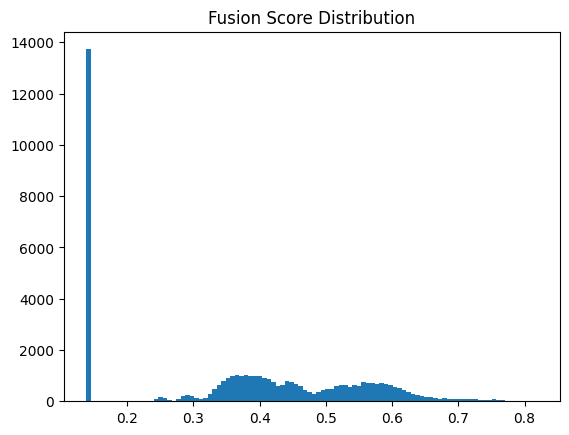

In [205]:
import matplotlib.pyplot as plt

plt.hist(df_final["fusion_score"], bins=100)
plt.title("Fusion Score Distribution")
plt.show()

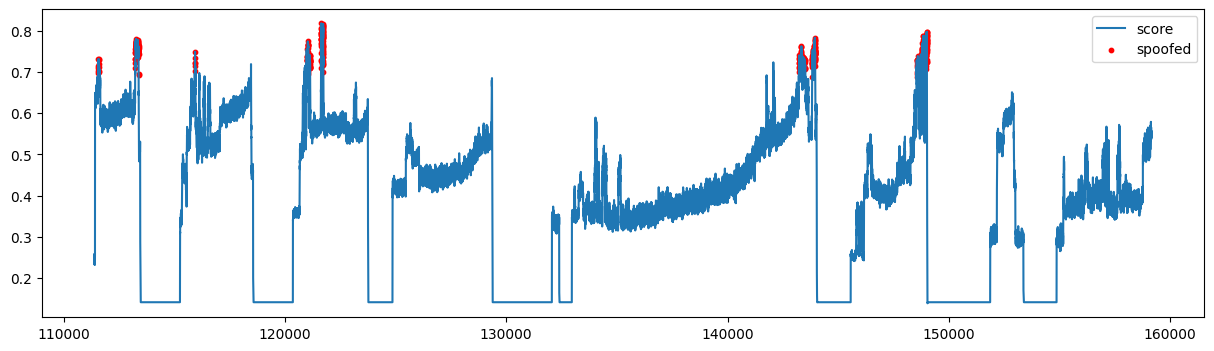

In [206]:
plt.figure(figsize=(15,4))
plt.plot(df_final["time"], df_final["fusion_score"], label="score")
plt.scatter(
    df_final["time"][df_final["final_spoofed"]==1],
    df_final["fusion_score"][df_final["final_spoofed"]==1],
    color="red", s=10, label="spoofed"
)
plt.legend()
plt.show()

In [207]:
sus_times = df_final[df_final["final_spoofed"]==1]["time"].head(10)

df[df["time"].isin(sus_times)].groupby("time")[["CN0","Pseudorange_m"]].std()

,CN0,Pseudorange_m
time,,
111571,23.310176,2.223102e+06
111572,23.297865,2.223100e+06
111573,23.267643,2.223097e+06
111574,23.268840,2.223095e+06
111575,23.249832,2.223093e+06
111582,23.235129,2.223076e+06
111583,23.218353,2.223074e+06
111584,23.218069,2.223072e+06
111585,23.221065,2.223069e+06
